# 07 - Physical Consistency Check

Two checks here: (1) do any model's holdout predictions break known physical bounds, purity in [0,1], duties non-negative, distillate purity not less than bottoms purity, and (2) does each model follow the expected direction of key process trends (reflux ratio vs purity/duty, feed composition vs purity) via synthetic sweeps, holding everything else at the training-set median.

In [7]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

## Bounds check on holdout predictions

In [8]:
input_columns = [
    "pressure_atm", "requested_vapor_fraction", "benzene_feed_fraction",
    "stages", "feed_stage_fraction", "reflux_ratio", "bottoms_fraction",
]
target_columns = ["x_D_benzene", "x_B_benzene", "Q_C", "Q_R"]

model_dir = "../models/01_trained_models_all_5"

rf_best = joblib.load(f"{model_dir}/random_forest.pkl")
xgb_best = joblib.load(f"{model_dir}/xgboost.pkl")
svr_best = joblib.load(f"{model_dir}/svr.pkl")
ann_best = joblib.load(f"{model_dir}/ann.pkl")
lin_final = joblib.load(f"{model_dir}/polynomial_regression.pkl")

scaler_X = joblib.load(f"{model_dir}/scaler_X.pkl")
scaler_y = joblib.load(f"{model_dir}/scaler_y.pkl")
poly = joblib.load(f"{model_dir}/poly_features.pkl")

lhs_df = pd.read_csv("../data/03_raw_holdout_lhs/lhs_500_converged.csv")
X_holdout = lhs_df[input_columns]
y_holdout = lhs_df[target_columns]

## Sensitivity sweep - reflux ratio

In [9]:
def get_predictions(model_name):

    # Random Forest
    if model_name == "RandomForest":
        return rf_best.predict(X_holdout)


    # XGBoost
    if model_name == "XGBoost":
        return xgb_best.predict(X_holdout)


    # SVR
    if model_name == "SVR":
        X_scaled = scaler_X.transform(X_holdout)
        return svr_best.predict(X_scaled)


    # ANN
    if model_name == "ANN":
        X_scaled = scaler_X.transform(X_holdout)
        pred_scaled = ann_best.predict(X_scaled)
        return scaler_y.inverse_transform(pred_scaled)


    # Polynomial Regression
    if model_name == "PolynomialRegression":
        X_poly = poly.transform(X_holdout)
        return lin_final.predict(X_poly)


models = [
    "RandomForest",
    "XGBoost",
    "SVR",
    "ANN",
    "PolynomialRegression"
]

violation_report = []

for name in models:
    pred = get_predictions(name)
    pred_df = pd.DataFrame(pred, columns=target_columns)

    xD_below0 = (pred_df["x_D_benzene"] < 0).sum()
    xD_above1 = (pred_df["x_D_benzene"] > 1).sum()

    xB_below0 = (pred_df["x_B_benzene"] < 0).sum()
    xB_above1 = (pred_df["x_B_benzene"] > 1).sum()

    QC_negative = (pred_df["Q_C"] < 0).sum()
    QR_negative = (pred_df["Q_R"] < 0).sum()

    ordering_violation = (
            pred_df["x_D_benzene"] < pred_df["x_B_benzene"]
    ).sum()

    violation_report.append({
        "model": name,
        "x_D_below_0": xD_below0,
        "x_D_above_1": xD_above1,
        "x_B_below_0": xB_below0,
        "x_B_above_1": xB_above1,
        "Q_C_negative": QC_negative,
        "Q_R_negative": QR_negative,
        "x_D_less_than_x_B": ordering_violation,
    })


violation_df = pd.DataFrame(violation_report).set_index("model")

print(violation_df)

violation_df.to_csv(
    "../data/06_physical_checks/bounds_violation_summary.csv"
)

                      x_D_below_0  x_D_above_1  x_B_below_0  x_B_above_1  \
model                                                                      
RandomForest                    0            0            0            0   
XGBoost                         0           40           59            0   
SVR                             0           82           70            0   
ANN                             0           50           25            0   
PolynomialRegression            0           90           88            0   

                      Q_C_negative  Q_R_negative  x_D_less_than_x_B  
model                                                                
RandomForest                     0             0                  0  
XGBoost                          0             0                  0  
SVR                              0             0                  0  
ANN                              0             0                  0  
PolynomialRegression             0             

## Sensitivity sweep - feed composition

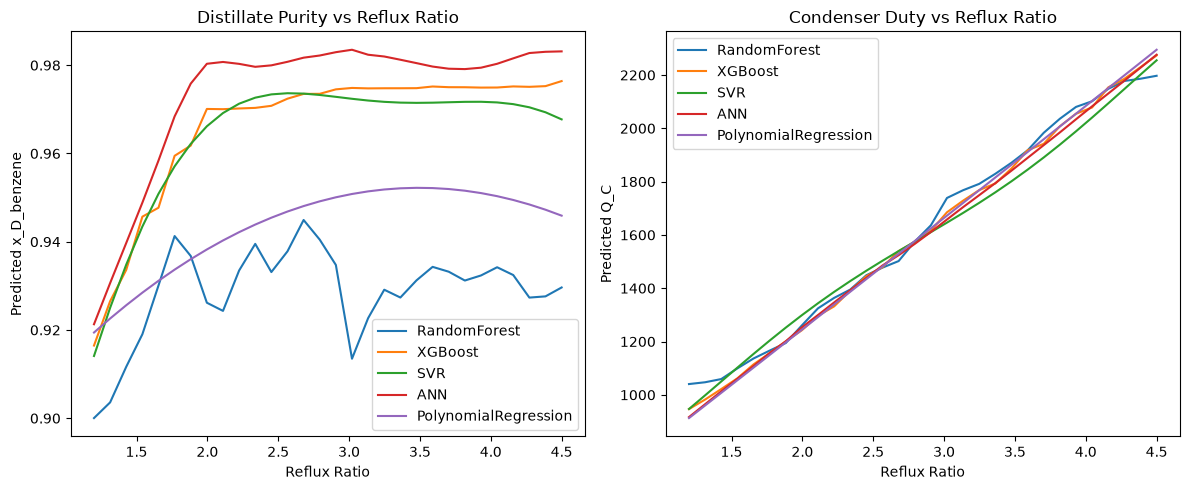

In [10]:
# Baseline
df_train = pd.read_csv(
    "../data/04_processed_dwsim/sobol_training_cleaned.csv"
)

baseline = df_train[input_columns].median()


# Prediction Sweep
def sweep(varying_col, values, model_name):

    rows = pd.DataFrame([baseline] * len(values))
    rows[varying_col] = values
    rows = rows[input_columns]

    # Random Forest
    if model_name == "RandomForest":
        pred = rf_best.predict(rows)

    # XGBoost
    elif model_name == "XGBoost":
        pred = xgb_best.predict(rows)

    # SVR
    elif model_name == "SVR":
        pred = svr_best.predict(
            scaler_X.transform(rows)
        )

    # ANN
    elif model_name == "ANN":
        pred_scaled = ann_best.predict(
            scaler_X.transform(rows)
        )
        pred = scaler_y.inverse_transform(pred_scaled)

    # Polynomial Regression
    elif model_name == "PolynomialRegression":
        pred = lin_final.predict(
            poly.transform(rows)
        )

    return pd.DataFrame(
        pred,
        columns=target_columns
    )


# Reflux Ratio Sweep
reflux_values = np.linspace(1.2, 4.5, 30)


# Plot
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for name in models:
    result = sweep(
        "reflux_ratio",
        reflux_values,
        name
    )

    axes[0].plot(
        reflux_values,
        result["x_D_benzene"],
        label=name
    )

    axes[1].plot(
        reflux_values,
        result["Q_C"],
        label=name
    )


# Distillate Purity
axes[0].set_xlabel("Reflux Ratio")
axes[0].set_ylabel("Predicted x_D_benzene")
axes[0].set_title("Distillate Purity vs Reflux Ratio")
axes[0].legend()


# Condenser Duty
axes[1].set_xlabel("Reflux Ratio")
axes[1].set_ylabel("Predicted Q_C")
axes[1].set_title("Condenser Duty vs Reflux Ratio")
axes[1].legend()


plt.tight_layout()

plt.savefig(
    "../outputs/plots/sensitivity_reflux_ratio.png",
    dpi=150
)

plt.show()

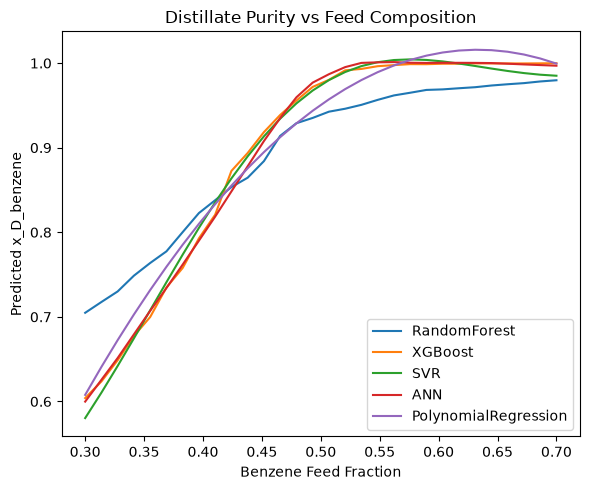

In [11]:
feed_values = np.linspace(0.30, 0.70, 30)

fig, ax = plt.subplots(figsize=(6, 5))

for name in models:
    result = sweep("benzene_feed_fraction", feed_values, name)
    ax.plot(feed_values, result["x_D_benzene"], label=name)

ax.set_xlabel("Benzene Feed Fraction")
ax.set_ylabel("Predicted x_D_benzene")
ax.set_title("Distillate Purity vs Feed Composition")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/plots/sensitivity_feed_composition.png", dpi=150)
plt.show()